<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/realestate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latvia real estate — price prediction (case study)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 3 — Deep learning trades explainability for capability — price that in  
**Rows:** 15,763  ·  **Source file:** `latvia_real_estate.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/latvia_real_estate.csv"
LOCAL = "latvia_real_estate.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (15763, 30)


,dataset_row_id,source_site,source_original,source_record_type,source_listing_id,source_url,scraped_at_utc,record_date,city,district,street_address,transaction_type,price_eur,price_period,area_m2,price_eur_per_m2,rooms,floor,total_floors,building_series,building_type,condition,year_built,latitude,longitude,has_elevator,has_balcony,has_parking,is_new_project,data_quality_flags
0,38346ef28ababbb6,city24.lv,city24.lv,listing,1473108,https://www.city24.lv/lv/real-estate/1473108,2026-07-06T18:23:29,2022-11-30,Rīga,Centrs,Rūpniecības iela 44,rent,2700.0,month,164.3,16.43,4.0,7.0,NaN,NaN,NaN,new_building,NaN,56.966440,24.104820,True,NaN,True,True,NaN
1,f7ded8b325fd3256,city24.lv,city24.lv,listing,2102145,https://www.city24.lv/lv/real-estate/2102145,2026-07-06T18:23:29,2022-11-30,Rīga,Centrs,Elizabetes iela 18,rent,1476.0,month,61.5,24.00,2.0,4.0,6.0,NaN,NaN,renovated,NaN,56.950247,24.121533,True,NaN,NaN,False,NaN
2,9b212a3143ba451d,city24.lv,city24.lv,listing,5918522,https://www.city24.lv/lv/real-estate/5918522,2026-07-06T18:23:29,2022-11-30,Rīga,Vecrīga,Miesnieku iela 13,rent,4260.0,month,157.8,27.00,4.0,4.0,6.0,NaN,NaN,renovated,NaN,56.949585,24.102472,True,True,NaN,False,NaN
3,d9b010f4b21de777,city24.lv,city24.lv,listing,3622097,https://www.city24.lv/lv/real-estate/3622097,2026-07-06T18:23:29,2022-12-15,Jūrmala,Dubulti,Dubultu prospekts,rent,800.0,month,113.0,7.08,4.0,2.0,3.0,NaN,NaN,NaN,NaN,56.965156,23.745734,NaN,NaN,NaN,False,NaN
4,c8413404a46c6c99,city24.lv,city24.lv,listing,1002904,https://www.city24.lv/lv/real-estate/1002904,2026-07-06T18:23:29,2022-12-19,Jūrmala,Dzintari,Dzintaru prospekts 13/15,rent,5000.0,month,200.0,25.00,4.0,3.0,8.0,NaN,NaN,NaN,NaN,56.978630,23.818938,NaN,NaN,NaN,False,NaN


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
dataset_row_id            str
source_site               str
source_original           str
source_record_type        str
source_listing_id         str
source_url                str
scraped_at_utc            str
record_date               str
city                      str
district                  str
street_address            str
transaction_type          str
price_eur             float64
price_period              str
area_m2               float64
price_eur_per_m2      float64
rooms                 float64
floor                 float64
total_floors          float64
building_series           str
building_type             str
condition                 str
year_built            float64
latitude              float64
longitude             float64
has_elevator           object
has_balcony            object
has_parking            object
is_new_project         object
data_quality_flags        str

Missing values:
record_date            7218
city                    132
district

---
## Problem 1 · Easy — describe

**Rīga is the market.** Filter to Rīga sale listings, then describe it properly:
median price, median €/m², and how €/m² differs across districts. Watch the
district labels carefully before you group by them.

*Try it yourself first. The worked solution is below.*

In [3]:
# ---------- 1. the Riga sale market ----------
sale = df[df["transaction_type"].astype(str).str.lower().str.startswith("sale", na=False)].copy()
riga = sale[sale["city"].astype(str).str.strip().str.lower().eq("rīga")].copy()
print(f"All listings          : {len(df):,}")
print(f"Sale listings         : {len(sale):,}")
print(f"Rīga sale listings    : {len(riga):,}  ({len(riga)/len(sale):.0%} of all sales)")

# ---------- 2. THE TRAP: the same district under two spellings ----------
raw = riga["district"].value_counts()
print("\nRaw district labels (top 8) — look closely:")
print(raw.head(8).to_string())
print("\n'Centrs' and 'centrs' are the SAME district split by capitalisation.")
riga["district"] = riga["district"].astype(str).str.strip().str.title()
print(f"Distinct districts before cleaning: {raw.size}   after: {riga['district'].nunique()}")

# ---------- 3. the honest market summary ----------
print(f"\nMedian price   : EUR {riga.price_eur.median():,.0f}")
print(f"Mean price     : EUR {riga.price_eur.mean():,.0f}   <-- mean >> median, right-skewed")
print(f"Median EUR/m2  : {riga.price_eur_per_m2.median():,.0f}")
print(f"Median area    : {riga.area_m2.median():.0f} m2")

dist = (riga.groupby("district")
             .agg(listings=("price_eur","size"),
                  median_price=("price_eur","median"),
                  median_eur_m2=("price_eur_per_m2","median"),
                  median_area=("area_m2","median"))
             .query("listings >= 40")
             .sort_values("median_eur_m2", ascending=False))
print("\nDistricts by EUR/m2 (>=40 listings):")
print(dist.round(0).to_string())
prem = dist["median_eur_m2"].iloc[0] / dist["median_eur_m2"].iloc[-1]
print(f"\nTop district is {prem:.1f}x the cheapest per square metre — that is the location premium.")

All listings          : 15,763
Sale listings         : 12,661
Rīga sale listings    : 7,044  (56% of all sales)

Raw district labels (top 8) — look closely:
district
Centrs        1602
centrs         803
Āgenskalns     493
Purvciems      331
Pļavnieki      323
Jugla          311
Ķengarags      300
Torņakalns     277

'Centrs' and 'centrs' are the SAME district split by capitalisation.
Distinct districts before cleaning: 60   after: 59

Median price   : EUR 146,750
Mean price     : EUR 187,472   <-- mean >> median, right-skewed
Median EUR/m2  : 2,528
Median area    : 61 m2

Districts by EUR/m2 (>=40 listings):
                        listings  median_price  median_eur_m2  median_area
district                                                                  
Vecrīga                      216      148595.0         3779.0         54.0
Skanste                       97      239000.0         3382.0         68.0
Mežaparks                     89      191000.0         3012.0         64.0
Centrs  

---
## Problem 2 · Intermediate — build

Now measure the drivers. Produce a **correlation matrix** for the numeric
features, then fit a **regression and read its table**: which variables move
price, by how much, and are the coefficients trustworthy? Model log price —
the target is skewed.

*Try it yourself first. The worked solution is below.*

In [4]:
import statsmodels.api as sm

sale = df[df["transaction_type"].astype(str).str.lower().str.startswith("sale", na=False)].copy()
riga = sale[sale["city"].astype(str).str.strip().str.lower().eq("rīga")].copy()
riga["district"] = riga["district"].astype(str).str.strip().str.title()
riga = riga[riga.price_eur.between(5_000, 2_000_000) & riga.area_m2.between(15, 400)]

# ---------- correlation matrix ----------
num = ["price_eur","price_eur_per_m2","area_m2","rooms","floor","total_floors","year_built"]
corr = riga[num].corr(numeric_only=True)
print("Correlation matrix (Pearson):")
print(corr.round(2).to_string())
print("""
Read it carefully:
  · area vs price is strong and positive — the obvious driver
  · rooms correlates with area, so they carry OVERLAPPING information
  · floor barely moves price on its own
  · year_built is missing for ~86% of rows, so its correlation is computed on a
    biased subset — do not trust it
""")

# ---------- regression table ----------
d = riga.dropna(subset=["price_eur","area_m2","rooms","floor","total_floors"]).copy()
d["ln_price"] = np.log(d["price_eur"])
d["ln_area"]  = np.log(d["area_m2"])

top_d = d["district"].value_counts().head(12).index          # keep the table readable
d = d[d["district"].isin(top_d)]
X = pd.get_dummies(d[["ln_area","rooms","floor","total_floors","district"]],
                   columns=["district"], drop_first=True).astype(float)
X = sm.add_constant(X)
model = sm.OLS(d["ln_price"], X).fit()
print(model.summary())

print("""
HOW TO READ THIS TABLE
  · Because the target is ln(price), a coefficient b means roughly a
    (e^b - 1) x 100 % change in price for a one-unit change in that variable.
  · ln_area near 1.0 would mean constant EUR/m2; below 1.0 means bigger flats
    cost LESS per square metre.
  · Each district coefficient is a premium (or discount) versus the omitted
    baseline district, holding size and floor constant. That is the number an
    estate agent is really trading on.
  · P>|t| under 0.05 is the usual bar. A large coefficient with a large p-value
    is noise, not a finding.
  · R-squared says how much of the variation you explain — not whether the model
    is fit to make decisions about a particular flat.
""")
b = model.params
print(f"ln_area coefficient: {b['ln_area']:.3f}  ->  a 10% larger flat costs "
      f"about {((1.10**b['ln_area'])-1)*100:.1f}% more in total")

Correlation matrix (Pearson):
                  price_eur  price_eur_per_m2  area_m2  rooms  floor  total_floors  year_built
price_eur              1.00              0.32     0.79   0.36   0.21          0.13        0.10
price_eur_per_m2       0.32              1.00     0.06   0.03   0.06          0.05        0.11
area_m2                0.79              0.06     1.00   0.47   0.21          0.11        0.07
rooms                  0.36              0.03     0.47   1.00   0.07          0.04        0.11
floor                  0.21              0.06     0.21   0.07   1.00          0.63        0.08
total_floors           0.13              0.05     0.11   0.04   0.63          1.00        0.11
year_built             0.10              0.11     0.07   0.11   0.08          0.11        1.00

Read it carefully:
  · area vs price is strong and positive — the obvious driver
  · rooms correlates with area, so they carry OVERLAPPING information
  · floor barely moves price on its own
  · year_built is 

---
## Problem 3 · Advanced — judge

Judge it. Compare the regression with a gradient-boosted model, find where the
error concentrates, quantify the district premium, and write the model card —
including what this data cannot support.

*Try it yourself first. The worked solution is below.*

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sale = df[df["transaction_type"].astype(str).str.lower().str.startswith("sale", na=False)].copy()
riga = sale[sale["city"].astype(str).str.strip().str.lower().eq("rīga")].copy()
riga["district"] = riga["district"].astype(str).str.strip().str.title()
riga = riga[riga.price_eur.between(5_000, 2_000_000) & riga.area_m2.between(15, 400)]
d = riga.dropna(subset=["area_m2","rooms","floor","total_floors"]).copy()

feat = ["area_m2","rooms","floor","total_floors","district"]
X = pd.get_dummies(d[feat], columns=["district"], drop_first=True).astype(float)
y = d["price_eur"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, random_state=42)

lin = LinearRegression().fit(Xtr, ytr)
gbr = GradientBoostingRegressor(random_state=42).fit(Xtr, ytr)
mape = lambda a, p: np.mean(np.abs(p - a) / a) * 100
rows = []
for name, m in [("Linear regression", lin), ("Gradient boosting", gbr)]:
    p = m.predict(Xte)
    rows.append({"model": name, "MAE_EUR": mean_absolute_error(yte, p),
                 "MAPE_%": mape(yte, p), "R2": r2_score(yte, p)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

# where does it go wrong?
p = gbr.predict(Xte)
err = pd.DataFrame({"actual": yte.values, "pred": p})
err["abs_err"] = (err.pred - err.actual).abs()
err["pct_err"] = err.abs_err / err.actual * 100
err["band"] = pd.qcut(err.actual, 4, labels=["cheapest 25%","lower-mid","upper-mid","priciest 25%"])
print("\nError by price band:")
print(err.groupby("band", observed=True)[["abs_err","pct_err"]].median().round(1).to_string())
print("\nAbsolute error grows with price; percentage error is usually worst at the")
print("cheap end. Which one matters depends on who is using the estimate.")

# district premium, holding size roughly constant
prem = (d.groupby("district")
          .agg(n=("price_eur","size"), med_m2=("price_eur_per_m2","median"))
          .query("n >= 40").sort_values("med_m2", ascending=False))
base = prem["med_m2"].median()
prem["premium_vs_median_%"] = ((prem["med_m2"] / base - 1) * 100).round(0)
print("\nDistrict premium vs the median Rīga district:")
print(prem.round(0).to_string())

print("""
MODEL CARD — Rīga apartment price estimator
  Intended use   : indicative guidance on ASKING price for a standard flat
  Not for        : lending, tax assessment, or any decision about a person
  Data           : scraped ASKING prices, not transaction prices
  Coverage       : Rīga sale listings only; other cities are out of scope
  Known missing  : condition and renovation (year_built absent for ~86% of rows),
                   floor plan, view, noise, energy class
  Known bias     : agents choose what to advertise, so the sample is not the market
  Failure modes  : luxury and micro-studios, new-build projects priced off-plan,
                   any district with few listings
  Review         : re-fit when listings shift; a scraped market moves under you
""")

            model   MAE_EUR  MAPE_%    R2
Linear regression 53367.804  38.367 0.640
Gradient boosting 48339.664  33.865 0.694

Error by price band:
              abs_err  pct_err
band                          
cheapest 25%  29543.5     55.3
lower-mid     14993.0     12.5
upper-mid     21424.1     12.5
priciest 25%  58000.2     17.3

Absolute error grows with price; percentage error is usually worst at the
cheap end. Which one matters depends on who is using the estimate.

District premium vs the median Rīga district:
                           n  med_m2  premium_vs_median_%
district                                                 
Vecrīga                  203  3767.0                 50.0
Skanste                   96  3389.0                 35.0
Mežaparks                 89  3012.0                 20.0
Āgenskalns               491  2834.0                 13.0
Centrs                  2336  2834.0                 13.0
Torņakalns               277  2787.0                 11.0
Pleskodāle-Ša

---
## Deep dive — the full picture

findfont: Failed to find font weight 600, now using 700.


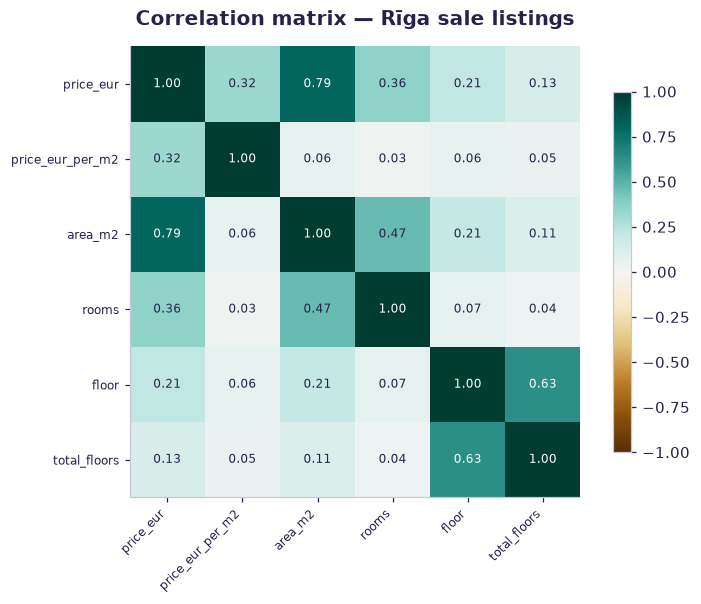

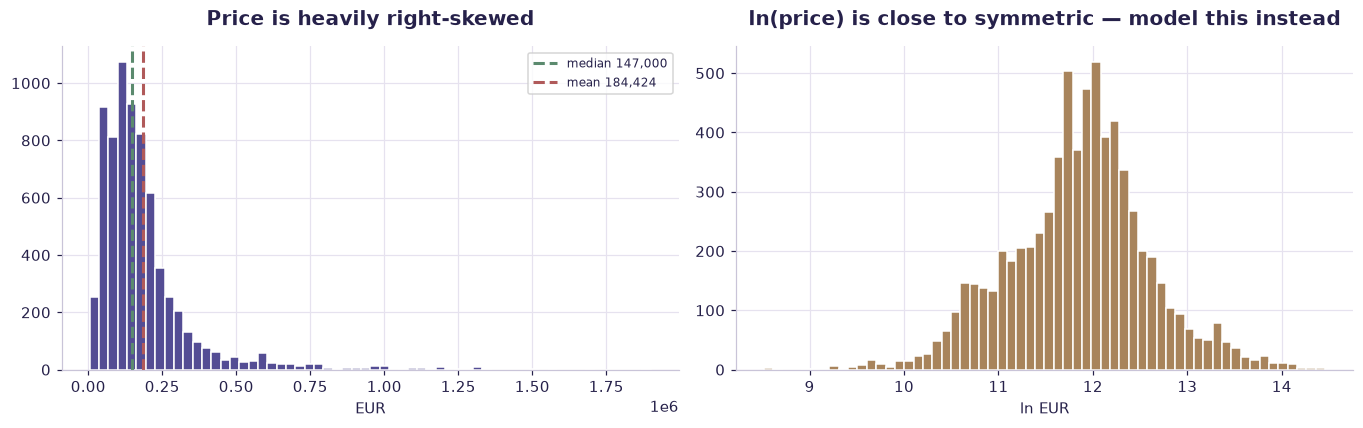

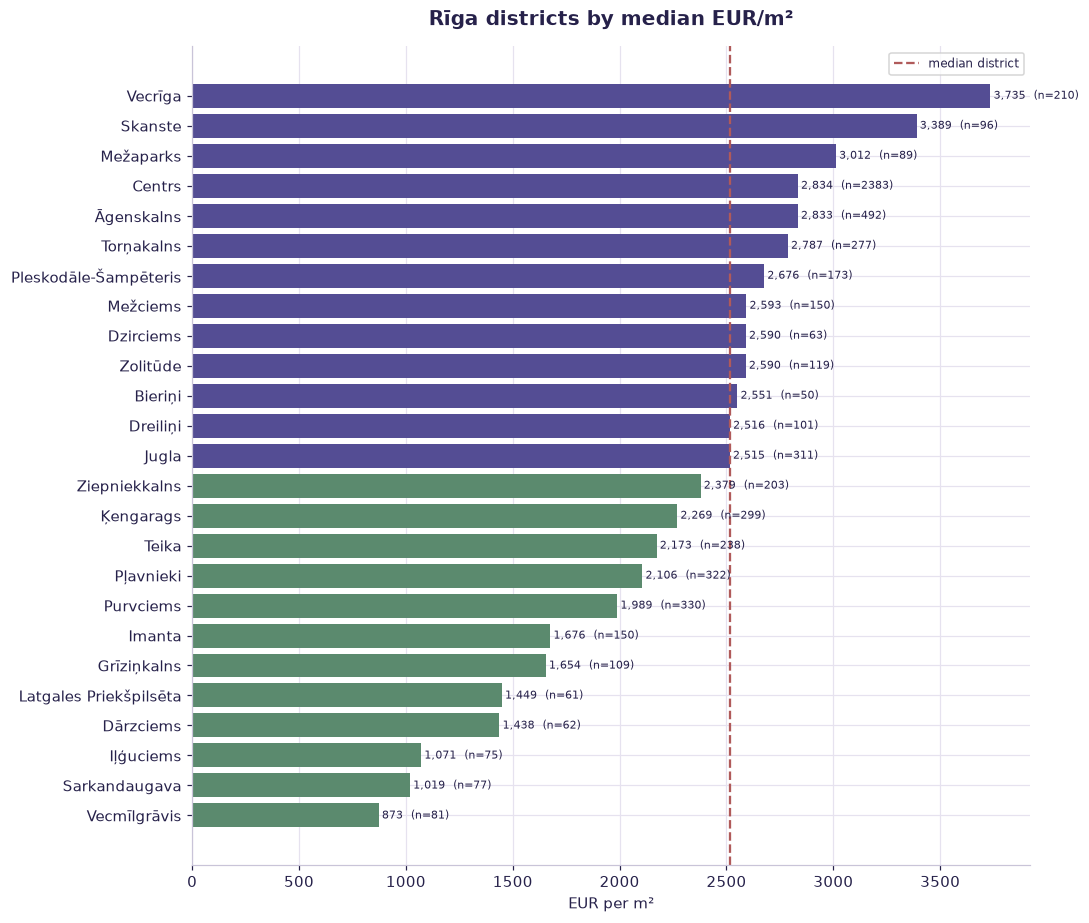

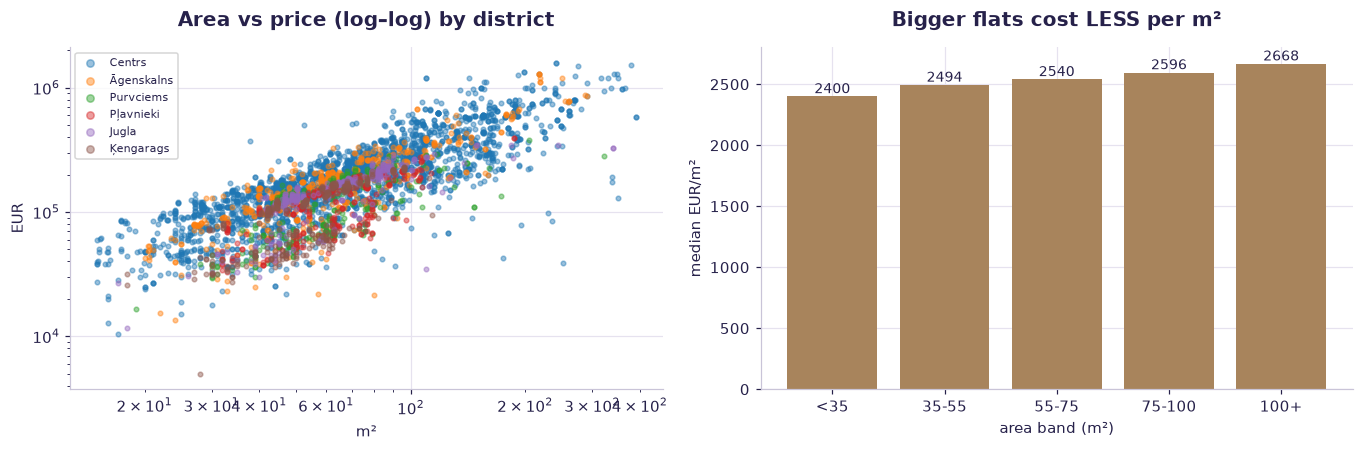

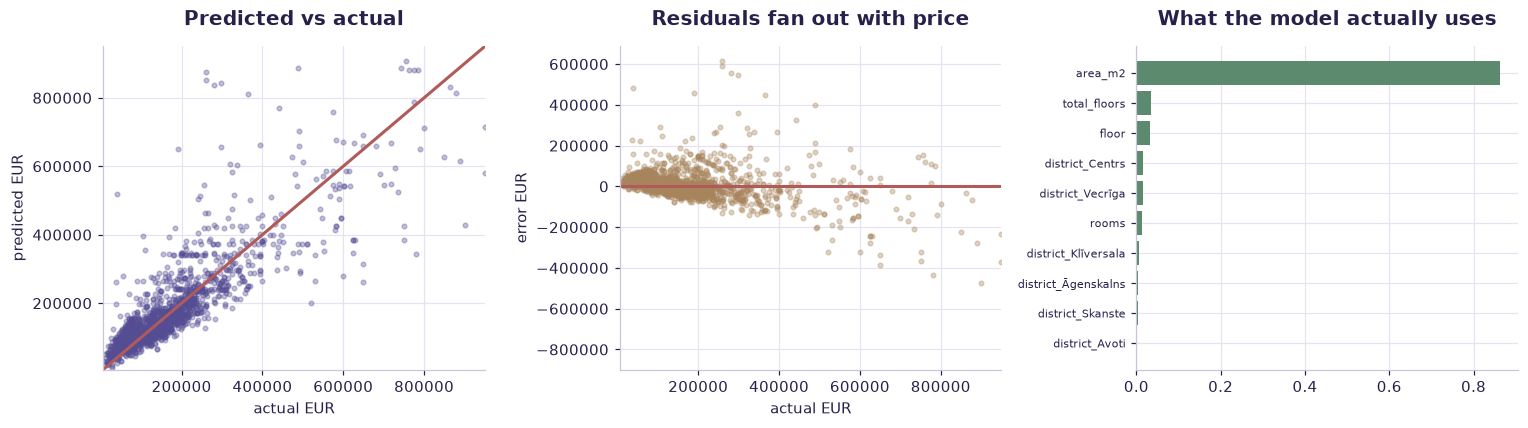

In [6]:
import matplotlib.pyplot as plt

sale = df[df["transaction_type"].astype(str).str.lower().str.startswith("sale", na=False)].copy()
riga = sale[sale["city"].astype(str).str.strip().str.lower().eq("rīga")].copy()
riga["district"] = riga["district"].astype(str).str.strip().str.title()
riga = riga[riga.price_eur.between(5_000, 2_000_000) & riga.area_m2.between(15, 400)]

# ---- 1. correlation heatmap ----
num = ["price_eur","price_eur_per_m2","area_m2","rooms","floor","total_floors"]
corr = riga[num].corr()
fig, ax = plt.subplots(figsize=(7.2, 5.6))
im = ax.imshow(corr, cmap="BrBG", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(num))); ax.set_yticklabels(num, fontsize=8)
for i in range(len(num)):
    for j in range(len(num)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i,j]) > .55 else INK)
ax.set_title("Correlation matrix — Rīga sale listings"); ax.grid(False)
fig.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()

# ---- 2. price distribution, raw vs log ----
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].hist(riga.price_eur, bins=60, color=ACCENT, edgecolor="white")
ax[0].axvline(riga.price_eur.median(), color=CORE, ls="--", lw=2, label=f"median {riga.price_eur.median():,.0f}")
ax[0].axvline(riga.price_eur.mean(), color=DANGER, ls="--", lw=2, label=f"mean {riga.price_eur.mean():,.0f}")
ax[0].set_title("Price is heavily right-skewed"); ax[0].set_xlabel("EUR"); ax[0].legend(fontsize=8)
ax[1].hist(np.log(riga.price_eur), bins=60, color=BUILDER, edgecolor="white")
ax[1].set_title("ln(price) is close to symmetric — model this instead"); ax[1].set_xlabel("ln EUR")
plt.tight_layout(); plt.show()

# ---- 3. district league table ----
dist = (riga.groupby("district")
             .agg(n=("price_eur","size"), med=("price_eur_per_m2","median"))
             .query("n >= 40").sort_values("med"))
fig, ax = plt.subplots(figsize=(10, max(4, .34*len(dist))))
cols = [CORE if v < dist["med"].median() else ACCENT for v in dist["med"]]
ax.barh(dist.index, dist["med"], color=cols)
ax.axvline(dist["med"].median(), color=DANGER, ls="--", lw=1.5, label="median district")
ax.set_title("Rīga districts by median EUR/m²"); ax.set_xlabel("EUR per m²"); ax.legend(fontsize=8)
for i, (v, n) in enumerate(zip(dist["med"], dist["n"])):
    ax.text(v + 15, i, f"{v:,.0f}  (n={n})", va="center", fontsize=7.5)
plt.tight_layout(); plt.show()

# ---- 4. size vs price, and the per-m2 effect ----
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
top6 = riga["district"].value_counts().head(6).index
for dname in top6:
    s = riga[riga.district == dname]
    ax[0].scatter(s.area_m2, s.price_eur, s=9, alpha=.45, label=dname)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_title("Area vs price (log–log) by district"); ax[0].set_xlabel("m²"); ax[0].set_ylabel("EUR")
ax[0].legend(fontsize=7, markerscale=1.6)

band = pd.cut(riga.area_m2, [0,35,55,75,100,400], labels=["<35","35-55","55-75","75-100","100+"])
g = riga.groupby(band, observed=True)["price_eur_per_m2"].median()
b = ax[1].bar(g.index.astype(str), g.values, color=BUILDER)
ax[1].bar_label(b, fmt="%.0f", fontsize=9)
ax[1].set_title("Bigger flats cost LESS per m²"); ax[1].set_xlabel("area band (m²)"); ax[1].set_ylabel("median EUR/m²")
plt.tight_layout(); plt.show()

# ---- 5. regression diagnostics ----
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
d = riga.dropna(subset=["area_m2","rooms","floor","total_floors"]).copy()
X = pd.get_dummies(d[["area_m2","rooms","floor","total_floors","district"]],
                   columns=["district"], drop_first=True).astype(float)
Xtr, Xte, ytr, yte = train_test_split(X, d["price_eur"], test_size=.25, random_state=42)
gbr = GradientBoostingRegressor(random_state=42).fit(Xtr, ytr)
pred = gbr.predict(Xte)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(yte, pred, s=9, alpha=.35, color=ACCENT)
lims = [yte.min(), yte.quantile(.99)]
ax[0].plot(lims, lims, color=DANGER, lw=2)
ax[0].set_xlim(lims); ax[0].set_ylim(lims)
ax[0].set_title("Predicted vs actual"); ax[0].set_xlabel("actual EUR"); ax[0].set_ylabel("predicted EUR")

resid = pred - yte.values
ax[1].scatter(yte, resid, s=9, alpha=.35, color=BUILDER)
ax[1].axhline(0, color=DANGER, lw=2)
ax[1].set_xlim(lims)
ax[1].set_title("Residuals fan out with price"); ax[1].set_xlabel("actual EUR"); ax[1].set_ylabel("error EUR")

imp = pd.Series(gbr.feature_importances_, index=X.columns).sort_values().tail(10)
ax[2].barh(imp.index, imp.values, color=CORE)
ax[2].set_title("What the model actually uses"); ax[2].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.show()

---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

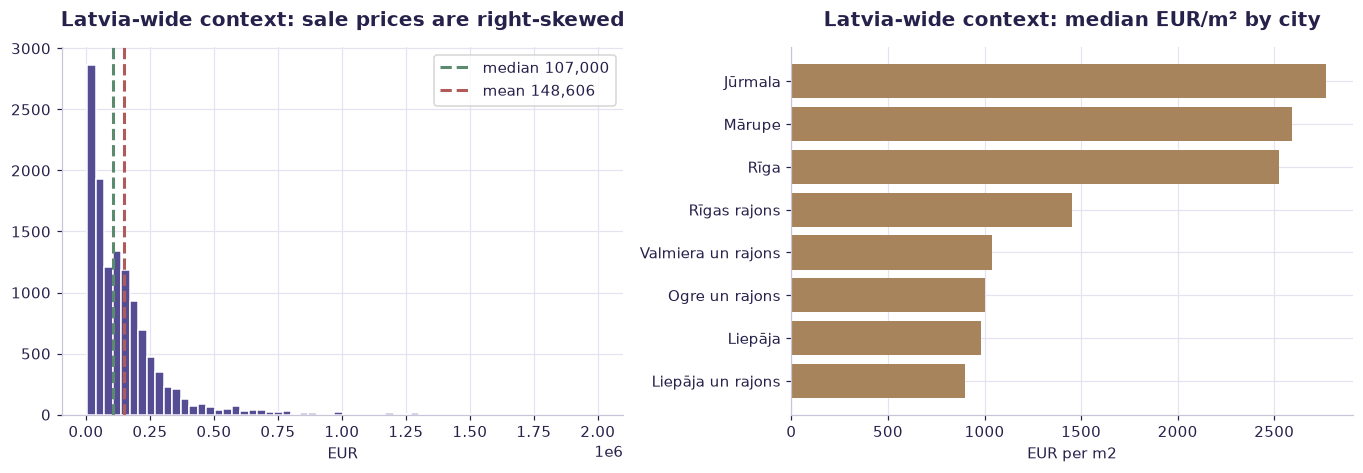

In [7]:
sale = df[df["transaction_type"].astype(str).str.lower().str.startswith("sale", na=False)]
sale = sale[sale.price_eur.between(5_000, 2_000_000)]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax[0].hist(sale["price_eur"], bins=60, color=ACCENT, edgecolor="white")
ax[0].axvline(sale.price_eur.median(), color=CORE, ls="--", lw=2, label=f"median {sale.price_eur.median():,.0f}")
ax[0].axvline(sale.price_eur.mean(), color=DANGER, ls="--", lw=2, label=f"mean {sale.price_eur.mean():,.0f}")
ax[0].set_title("Latvia-wide context: sale prices are right-skewed"); ax[0].set_xlabel("EUR"); ax[0].legend()

m = (sale.groupby("city")["price_eur_per_m2"].agg(n="size", med="median")
        .query("n >= 50").sort_values("med").tail(8))
ax[1].barh(m.index, m["med"], color=BUILDER)
ax[1].set_title("Latvia-wide context: median EUR/m² by city"); ax[1].set_xlabel("EUR per m2")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. 15,763 listings: 12,661 sale, 3,102 rent. Rīga = 9,033 (57%), then Jūrmala, Jelgava, Daugavpils. Rīga alone holds 7,418 sale listings — the notebook analyses that market
2. Sale price: median €100,100, mean €146,425 — right-skewed, so model the median / log-price, not the mean
3. Target choice matters, and the comparison must be fair: predicting €/m² then multiplying by area gives a LOWER relative error (MAPE ≈55% vs ≈59%) but a slightly higher absolute error (MAE ≈€47.9k vs ≈€47.1k). R² across different targets is not comparable — convert back to one target before judging
4. Rīga district spread is 4.3x: Vecrīga ≈€3,735/m² and Skanste ≈€3,389 at the top, Vecmīlgrāvis ≈€873 and Sarkandaugava ≈€1,019 at the bottom (districts with ≥40 listings)
5. DATA TRAP: district labels are split by capitalisation — 'Centrs' (2,034) and 'centrs' (1,356) are the same place. Group before you clean and you halve Rīga's biggest district
6. OLS on ln(price) for Rīga reaches R² ≈ 0.70; ln_area ≈ 1.02 (near-constant €/m² once district is controlled for) while rooms is NOT significant (p ≈ 0.51) — it is collinear with area
7. Data caveat: scraped ASKING prices, not sale prices; year_built is missing for ~86% of Rīga sale rows, so any age effect is computed on a biased subset


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Deployment checklist for one deep-learning use case (data, compute, interpretability, monitoring, owner).

---
*Applied AI Academy · appliedai.center*
